# **Homework3: Neural Network structure**

 - Answer the questions marked with **Questions # )** . Just answer the parts where it says: **" write your answer here. "**
 > **you should write the codes here in this notebook.**

 * Total score: 100 score and 20 bonus additive points
 * Bonus questions are optional and their score is additive only for this homework.
 *  **Do not** alter the pre-written code. You can add or remove arguments to the functions but **do not** remove any function.
 * Full report of how you did the homework is needed.




## **Custom Neural Network with backpropagation**

Imagine you're a brilliant neuroscientist constructing a brand new custom neural network from scratch!<br>

Your network must have two phases: A feedforward phase and a backpropagation phase.<br>

To represent individual neurons (artificial neurons), you'll need a Neuron class. Then, you'll combine these Neurons into layers using a Layer class. Finally, you'll connect these layers to form the complete NeuralNetwork. Let's write the code for these classes!

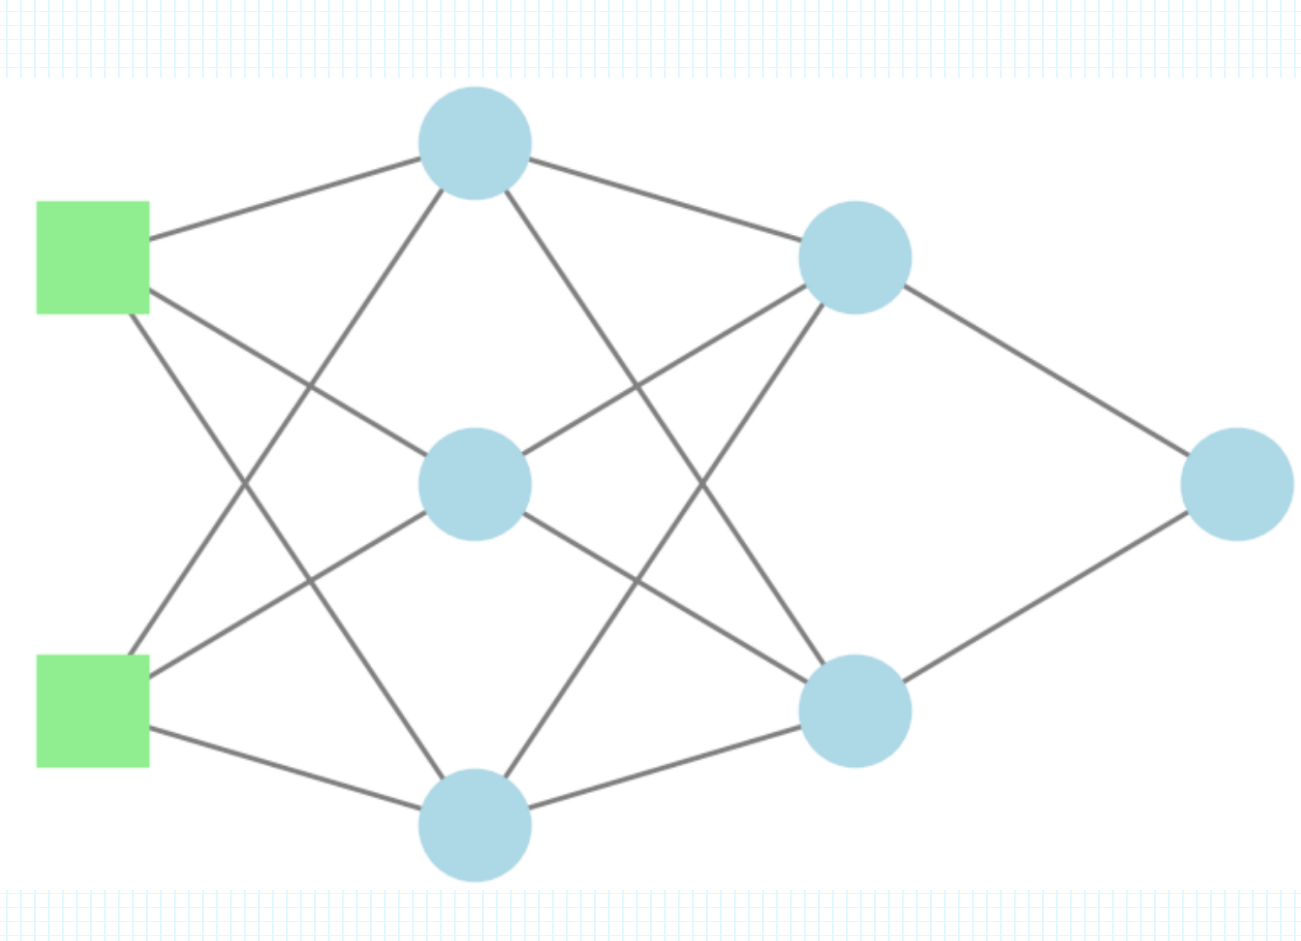

First we import numpy as usual:

In [1]:
import numpy as np

Then we'll need activation functions to help us define our network.

### Activation Functions


**Question 1-a ) (10 points)** Write methods for various activation functions, such as sigmoid, ReLU, Leaky ReLU, tanh, sign, and linear. Each method should take an input value and return the corresponding activation function output.

In [2]:
def sigmoid(x):
    output = 1 / (1 + np.exp(-x))
    return output
    
def relu(x):
    output = np.maximum(0, x)
    return output

def leaky_relu(self, x):
    alpha = 0.1
    output = np.maximum(alpha * x, x)
    return output

def tanh(x):
    output = np.tanh(x)
    return output

def sign(x):
    output = np.sign(x)
    return output

def linear(x):
    return x

The following 3 classes are needed to define our simple network. network class uses the layer class, and the layer class uses the neuron class.

### **Neuron class**

**Question 1-b) (10 points)** Create a class named Neuron with the following functionalities:<br>

*   Constructor: It should take arguments for the number of inputs to the neuron (n_inputs), an optional list of pre-defined weights (input_w), an optional activation function name (activation), and an optional seed (seed) for random number generation.
If input_w is not provided, the constructor should initialize random weights using the seed and a bias of 0.
*   Calculate method: The Neuron needs a method named calculate that takes an array of input values. This method performs the following steps:
Calculates the weighted sum of the inputs using the dot product of weights and inputs, along with the bias term.
Applies the chosen activation function to the weighted sum.
Returns the final output value of the Perceptron.
*   Backpropagate method: The backpropagate method in the Neuron class calculates the neuron's contribution to the overall error and updates its weights and bias based on that error.Steps: Calculate the derivative of the activation function (delta_w), Calculate the delta for the neuron (delta), Update weights and bias.


In [3]:
class Neuron:
    """
    Represents a single perceptron (artificial neuron) in the network.
    """
    def __init__(self, n_inputs, input_w=None, activation="sigmoid", seed = None):
        """
        Initializes the perceptron with random/custom weights and an activation function.
        
        Args:
            n_inputs (int): Number of inputs to the perceptron.
            input_w (list/array or None): list of weights entering the neuron
            activation (str, optional): Activation function to use. Defaults to "sigmoid".
            seed (int, optional): Seed for the random number generator. Defaults to None.
        """

        # Initialize weights and bias for the neuron
        np.random.seed(seed)
        if input_w is None:
            self.weights = 0.1 * np.random.randn(n_inputs)
            self.bias = 0
        else:
            self.weights = np.array(input_w[1:], dtype=np.float64)
            self.bias = input_w[0]

        # Supported activation functions and their derivatives
        activation_functions = {
            'relu' : (relu, lambda x: np.where(x > 0, 1, 0)),
            'sigmoid' : (sigmoid, lambda x: sigmoid(x) * (1 - sigmoid(x))),
            'leaky_relu' : (leaky_relu, lambda x: np.where(x > 0, 1, 0.1)),
            'tanh' : (tanh, lambda x: 1 - np.tanh(x) ** 2),
            'sign' : (sign, lambda x: np.where(x > 0, 1, -1)),
            'linear' : (linear, lambda x: 1)}

        try:
            self.activation, self.derivative = activation_functions[activation]
        except:
            raise Exception("The entered activation function is not supported.")

    def calculate(self, inputs):
        """
        Calculates the output of the perceptron given a set of inputs.
        
        Args:
            inputs (np.ndarray): Array of input values.
        
        Returns:
            float: The activated output of the perceptron.
        """
        # Forward pass in neuron: activation(weight * inputs + bias)
        self.inputs = np.array(inputs, dtype=np.float64)
        self.output = np.dot(inputs, self.weights) + self.bias
        return self.activation(self.output)
        

    def backpropagate(self, learning_rate, error):
        """
        Performs backpropagation on the neuron based on the learning rate and error.
        
        Args:
            learning_rate (float): Learning rate for weight updates.
            error (float): Error signal from the next layer.
        """
        # Calculate delta based on the error of the previous layer
        delta = error * self.derivative(self.output)

        # Calculate error of this layer
        error = error * self.weights

        # Update weights and bias base on delta
        self.weights += learning_rate * delta * self.inputs
        self.bias += learning_rate * delta
        
        return error
        

### **Layer class**

**Question 1-c) (10 points)** Create a class named Layer with the following functionalities:<br>


*   Constructor:
It should take arguments for the number of neurons in the layer (n_neurons), the number of inputs which is recieved from the previous layer (n_inputs), an optional list of lists for pre-defined weights (input_w), and an optional activation function name (activation).
Inside the constructor, create a list to store Perceptron objects.

*   Calculate method:
Define a method named calculate that takes an array of input values.
This method should iterate through the Perceptrons in the layer, feeding the input values through each Perceptron's calculate method and collecting the outputs.
Finally, return an array containing the outputs from all Perceptrons in the layer.
*   Backpropagate method: performs backpropagation for all the neurons within that layer.Steps:Iterate Through Neurons, Retrieve Error, Backpropagate in Neuron.







In [4]:
class Layer:
    """ Represents a layer in the neural network, containing multiple Perceptrons (Neurons). """
    def __init__(self, n_neurons, n_inputs, input_w=None, activation="sigmoid", seed = None):
        """
        Initializes the layer with a list of Neurons.
        
        Args:
            n_neurons (int): Number of neurons in the layer.
            n_inputs (int): Number of neurons in the previous layer.
            input_w (list/array or None): list of weights for each neuron
            activation (str, optional): Activation function to use for all neurons. Defaults to "sigmoid".
            seed (int, optional): Seed for the random number generator. Defaults to None.
        """

        # Initialize neurons of the layer
        self.neurons = []
        if input_w is not None:
            for i in range(n_neurons):
                self.neurons.append(Neuron(n_inputs, input_w[i], activation, seed))
        else:
            for i in range(n_neurons):
                self.neurons.append(Neuron(n_inputs, None, activation, seed))

    def calculate(self, inputs):
        """
        Calculates the outputs of all neurons in the layer given a set of inputs.
        
        Args:
            inputs (np.ndarray): Array of input values.
        
        Returns:
            np.ndarray: Array of outputs from each neuron in the layer.
        """
        
        # Forward pass in layer
        outputs = []
        for neuron in self.neurons:
            output = neuron.calculate(inputs)
            outputs.append(output)
        return np.array(outputs)
        

    def backpropagate(self, learning_rate, errors):
        """
        Performs backpropagation on all neurons in the layer.
        
        Args:
            learning_rate (float): Learning rate for weight updates.
            errors (np.ndarray): Array of error signals from the next layer.
        """
        # Calculate the error of each neuron and then sum them to calculate the error of the layer.
        layer_errors = np.zeros_like(self.neurons[0].inputs, dtype=np.float64)
        for i, neuron in enumerate(self.neurons):
            layer_errors += neuron.backpropagate(learning_rate, errors[i])
        return layer_errors


### **NeuralNetwork class**

**Question 1-d) (10 points)** The NeuralNetwork class represents the complete neural network structure. It will take care of creating and connecting layers, handling pre-defined weights (if provided), and performing computations (feedforward propagation) on the input data.

*   Define the Network: During initialization, it takes a list specifying the number of neurons in each layer (list_of_n_neurons), optional activation functions for each layer (list_of_activation_functions), and optional pre-defined weight matrices for connections between layers (list_of_weights). It creates a list of layers to work with.
*   Validation check: It will perform checks to ensure the provided arguments are valid (e.g., at least two layers, matching list lengths).
*   Build Layer by Layer: It will iterate through list_of_n_neurons to create layers. For each layer (except the first), the number of inputs will be the previous layer's neuron count. When creating layers, it will pass:
The number of neurons in the current layer.
The number of inputs each Perceptron receives (from the previous layer or the first layer's input size).
A sub-matrix of pre-defined weights (if list_of_weights is provided).
The activation function for the layer (from list_of_activation_functions or default).
*   Feedforward magic: It will have a feedforward method that takes an input array and performs the core computation (feedforward propagation):
Convert the input list to a NumPy array.
Iterate through each layer:
Pass the current layer's output to its calculate method.
Collect the resulting output from each layer.
Return the final network output (from the last layer's calculation).
*   Backpropagation method: initiates the backpropagation process for the entire network, starting from the final layer and propagating errors backwards through all layers.

By building these classes progressively, you'll have all the necessary components to construct and utilize this simple neural network!

In [5]:
class NeuralNetwork:
    """ Represents the entire feedforward neural network. """
    def __init__(self, list_of_n_neurons, list_of_activation_functions=None, list_of_weights=None, seed=None):
        """
        Initializes the neural network.
        
        Args:
            list_of_n_neurons (list): List specifying the number of neurons in each layer.
            list_of_activation_functions (list, optional): List specifying the activation function for each layer. Defaults to None (all sigmoid).
            list_of_weights (list, optional): List specifying pre-defined weights for each layer. Defaults to None (random weights).
            seed (int, optional): Seed for random number generator. Defaults to None.
        """
        self.layers = []
    
        if len(list_of_n_neurons) < 2:
          raise Exception("Cannot make a Neural network with 1 or less layers.")
    
        # Check for valid input regarding activation functions and weights
        if (list_of_activation_functions != None and (len(list_of_activation_functions) != len(list_of_n_neurons) or list_of_activation_functions[0] != None)):
          raise Exception("List_of_activation_functions is wrong.")
        if (list_of_weights != None and (len(list_of_weights) != len(list_of_n_neurons) or list_of_weights[0] != None)):
          raise Exception("List_of_weights is wrong.")
    
        for i in range(1, len(list_of_n_neurons)):
          # Check for weight compatibility if weights are provided
          if list_of_weights != None:
            for item in list_of_weights[i]:
              if len(item) != (list_of_n_neurons[i-1] + 1):
                raise Exception("List_of_weights is entered wrong")
    
        # Create layers based on input configuration
        if list_of_activation_functions == None and list_of_weights == None:
            for i in range(1, len(list_of_n_neurons)):
                self.layers.append(
                    Layer(list_of_n_neurons[i], list_of_n_neurons[i - 1], seed=seed))
        elif list_of_activation_functions == None and list_of_weights != None:
            for i in range(1, len(list_of_n_neurons)):
                self.layers.append(
                    Layer(list_of_n_neurons[i], list_of_n_neurons[i - 1], input_w=list_of_weights[i], seed=seed))
        elif list_of_activation_functions != None and list_of_weights == None:
            for i in range(1, len(list_of_n_neurons)):
                self.layers.append(
                    Layer(list_of_n_neurons[i], list_of_n_neurons[i - 1], activation=list_of_activation_functions[i], seed=seed))
        else:
            for i in range(1, len(list_of_n_neurons)):
                self.layers.append(
                    Layer(list_of_n_neurons[i], list_of_n_neurons[i - 1], activation=list_of_activation_functions[i], input_w=list_of_weights[i], seed=seed))

    def feedforward(self, inputs):
        """
        Performs feedforward propagation on the input data and returns the final output.
        
        Args:
            inputs (list): List of input values (simpler than np.ndarray).
        
        Returns:
            float: The final output of the network.
        """
        # Feedforward through the network's layers
        self.input = inputs
        for layer in self.layers:
            inputs = layer.calculate(inputs)
        return inputs
    
    def backpropagate(self, learning_rate, targets):
        """
        Performs backpropagation on the network based on the learning rate and target values.
        
        Args:
            learning_rate (float): Learning rate for weight updates.
            targets (np.ndarray): Array of target values for each input data point.
        """
        # Feedforward through the network to calculate outputs
        outputs = self.feedforward(self.input)

        # Calculate the derivative of the loss function (MSE) with respect to the outputs
        loss_grad = -2 * (outputs - targets)

        # Backpropagate through the network's layers
        for layer in reversed(self.layers):
            loss_grad = layer.backpropagate(learning_rate, loss_grad)


NeuralNetwork input format:



*   list_of_n_neurons: a list of numbers of neurons in each layer containing the input layer. for example [2, 2, 1] is a 3 layered network with 2 inputs and a hidden layer with 2 neurons and an output layer with 1 neuron.
*   list_of_activation_functions: a list of activation functions for each layer. It is assumed that every neuron in each layer should have the same activation function. first element is always None as the input layer has no activation function.
*   list_of_weights: a list that has a first element that is None. the rest are lists of weights for layers. for example [None, [[3,2,2],[3,2,2]], [[4,2,2]]]. for the first layer we have 2 neurons therefore two sets of lists for the weights. the first element of each list is bias for that neuron. Here for the first neuron 3 is bias, then 2 and 2 are the weights entering to the first node of that layer.

Some notes:


*   In creating objects of the Layer class in NeuralNetwork you can ignore the
first layer beacuse they are inputs. for example, in a 3 layered network, you should have 2 Layer object in NeuralNetwork class excluding the input layer.
*   list_of_activation_functions and list_of_weights can be None so try to handle it in the NeuralNetwork class.


### Classification using our network (feed forward without backpropagation and training)

**Question 1-e) (30 points)** Now lets try the feedforward pass of our network. we are given the required input for the network. write a function that feeds each data to the network and predicts its label by rounding the result, print the predicted labels, then calculate the total accuracy.

In [6]:
seed_value = 40

list_of_n_neurons = [2, 3, 2, 1]
list_of_activation_functions = [None, "sigmoid", "sigmoid", "sigmoid"]
list_of_weights = [None, [[6.6263,1.251,-3.1725],[1.1956,-2.9605,4.5407],[6.8663,-2.6636,-2.6909]],
                         [[5.2807,-4.4324,-3.3685,-4.3834],[-4.4471,3.438,3.1342,4.1027]], [[-0.24816,-9.6592,7.9743]]]
network = NeuralNetwork(list_of_n_neurons, list_of_activation_functions, list_of_weights, seed=seed_value)

input_data = np.array([ [1, 2], [2, 1], [3, 3], [1, 3], [3, 1], [4, 4]])
true_labels = np.array([1, 1, 1, 0, 0, 0])

def function(input_data, true_labels, network):
    predictions = []
    for input in input_data:
        predictions.append(network.feedforward(input))
    predictions = np.round(predictions).flatten()
    accuracy = ((predictions == true_labels).sum() / len(true_labels)) * 100
    return accuracy

function(input_data, true_labels, network)

100.0

### Classification using our network (full training)

**Question 1-f) (30 points)** Now lets train our network. we are given the required input for the network. write a function that feeds each data to the network in each epoch and backpropagates the errors until a certain epoch is reached, just using the Neural network class attributes and functions.

In [7]:
seed_value = 40

list_of_n_neurons = [2, 3, 2, 1]
list_of_activation_functions = [None, "sigmoid", "sigmoid", "sigmoid"]
list_of_weights = [None, [[0.3057821,-0.30289,2.0777],[1.7295314,-0.29038,-1.3218],[-2.1086906,-1.2375,-1.1397]],
                         [[1.3347095,-0.72415,1.227,0.371719],[-0.435759,-1.8449,2.5112,-1.2922]],
                         [[-0.88386,-0.93309,-0.87118]]]
network = NeuralNetwork(list_of_n_neurons, list_of_activation_functions, list_of_weights, seed=seed_value)

X_train = np.array([ [1, 2], [2, 1], [3, 3], [1, 3], [3, 1], [4, 4]])
y_train = np.array([1, 1, 1, 0, 0, 0])

# Define learning rate and number of epochs
learning_rate = 0.1
epochs = 1000
n_loss = []
n_accuracy = []

# Training
for epoch in range(1, epochs + 1):
    prediction = []
    loss = []
    for X, y in zip(X_train, y_train):
        # Forward pass
        outputs = network.feedforward(X)
        prediction.append(outputs)
        # Compute loss (Mean Squared Error)
        loss.append((outputs - y) ** 2)
        # Backpropagate
        network.backpropagate(learning_rate, y)
        
    # Calculate loss and accuracy on the training data in each epoch
    prediction = np.round(prediction).flatten()
    accuracy = ((prediction == true_labels).sum() / len(true_labels)) * 100    
    n_loss.append(np.mean(loss))
    n_accuracy.append(accuracy)
    
    if epoch % 50 == 0:
        print(f'Epoch: {epoch} / {epochs},\t Loss: {np.mean(loss):.3f},\t Accuracy: {accuracy:.2f}%')

Epoch: 50 / 1000,	 Loss: 0.254,	 Accuracy: 50.00%
Epoch: 100 / 1000,	 Loss: 0.253,	 Accuracy: 50.00%
Epoch: 150 / 1000,	 Loss: 0.248,	 Accuracy: 50.00%
Epoch: 200 / 1000,	 Loss: 0.242,	 Accuracy: 50.00%
Epoch: 250 / 1000,	 Loss: 0.233,	 Accuracy: 66.67%
Epoch: 300 / 1000,	 Loss: 0.224,	 Accuracy: 66.67%
Epoch: 350 / 1000,	 Loss: 0.216,	 Accuracy: 66.67%
Epoch: 400 / 1000,	 Loss: 0.211,	 Accuracy: 66.67%
Epoch: 450 / 1000,	 Loss: 0.208,	 Accuracy: 66.67%
Epoch: 500 / 1000,	 Loss: 0.204,	 Accuracy: 66.67%
Epoch: 550 / 1000,	 Loss: 0.195,	 Accuracy: 66.67%
Epoch: 600 / 1000,	 Loss: 0.179,	 Accuracy: 66.67%
Epoch: 650 / 1000,	 Loss: 0.156,	 Accuracy: 100.00%
Epoch: 700 / 1000,	 Loss: 0.135,	 Accuracy: 83.33%
Epoch: 750 / 1000,	 Loss: 0.056,	 Accuracy: 100.00%
Epoch: 800 / 1000,	 Loss: 0.026,	 Accuracy: 100.00%
Epoch: 850 / 1000,	 Loss: 0.017,	 Accuracy: 100.00%
Epoch: 900 / 1000,	 Loss: 0.013,	 Accuracy: 100.00%
Epoch: 950 / 1000,	 Loss: 0.010,	 Accuracy: 100.00%
Epoch: 1000 / 1000,	 Loss:

# Bonus questions

**Question 1-g) (20 points)**  plot the accuracy and error in the training process for the last question.

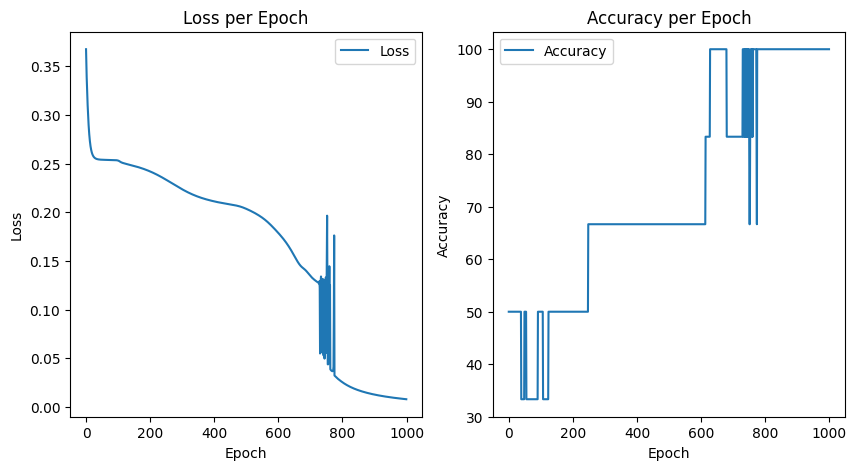

In [8]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Plot loss vs epochs
ax1.plot(n_loss, label='Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss per Epoch')
ax1.legend()

# Plot accuracy vs epochs
ax2.plot(n_accuracy, label='Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy per Epoch')
ax2.legend()

plt.show()